In [1]:
import Pkg
Pkg.add(["MultiFloats", "GenericFFT", "Plots", "FFMPEG",  "AbstractFFTs", "LaTeXStrings", "NumericalIntegration"])

   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`


In [2]:
using MultiFloats
using GenericFFT
using AbstractFFTs
using LinearAlgebra
using Plots
using LaTeXStrings
using NumericalIntegration

MultiFloats.use_bigfloat_transcendentals()

"""
Computes the critical bifurcation parameters for a given mode j.
"""
function critical_bifurcation(j, L, mass, ::Type{T}) where {T}
    k_j = 2 * T(pi) * T(j) / T(L)
    mu_j = 3 * T(mass)^2 + k_j^2
    return mu_j, k_j
end

"""
Computes the ETDRK4 integration coefficients using a complex contour integral.
"""
function compute_etdrk4_coefficients(L_operator, dt_float::Float64, ::Type{T}) where {T}
    dt = T(dt_float)
    M = 64  # Number of points on the contour circle
    Nx = length(L_operator)
    
    # Define roots of unity for the circle contour integration
    r = [exp(im * T(pi) * (T(k) - T(0.5)) / T(M)) for k in 1:M]
    
    # Pre-allocate coefficient arrays
    E  = zeros(T, Nx)
    E2 = zeros(T, Nx)
    Q  = zeros(T, Nx)
    f1 = zeros(T, Nx)
    f2 = zeros(T, Nx)
    f3 = zeros(T, Nx)
    
    # In-place evaluation for linear filters
    @. E  = exp(dt * L_operator)
    @. E2 = exp(dt * L_operator / 2)
    
    for i in 1:Nx
        z = dt * L_operator[i]
        
        sum_Q  = zero(Complex{T})
        sum_f1 = zero(Complex{T})
        sum_f2 = zero(Complex{T})
        sum_f3 = zero(Complex{T})
        
        for lr in (z .+ r)
            exp_lr_2 = exp(lr / 2)
            exp_lr   = exp(lr)
            
            sum_Q  += (exp_lr_2 - 1) / lr
            sum_f1 += (-4 - lr + exp_lr * (4 - 3*lr + lr^2)) / (lr^3)
            sum_f2 += (2 + lr + exp_lr * (-2 + lr)) / (lr^3)
            sum_f3 += (-4 - 3*lr - lr^2 + exp_lr * (4 - lr)) / (lr^3)
        end
        
        Q[i]  = dt * real(sum_Q / T(M))
        f1[i] = dt * real(sum_f1 / T(M))
        f2[i] = dt * real(sum_f2 / T(M))
        f3[i] = dt * real(sum_f3 / T(M))
    end
    
    return E, E2, Q, f1, f2, f3
end

"""
Mutating helper function to compute the Cahn-Hilliard non-linear forcing term N(u) 
completely in-place, preventing allocations inside the time-stepping engine.
"""
function compute_nonlinear_forcing_hat!(N_hat, u, mu, Laplacian_k, dealias_mask, u3_scratch)
    @. u3_scratch = u^3 - mu * u
    
    # Structural FFT allocation-free assignment (or out-of-place functional fallback)
    u3_hat = fft(u3_scratch) 
    
    @. N_hat = dealias_mask * Laplacian_k * u3_hat
end

"""
Optimized ETDRK4 Time Stepping Engine utilizing full in-place loop fusion.
"""
function solve_etdrk4!(
    u::Vector{T}, 
    num_time_steps::Int, 
    t_vec::StepRangeLen,
    mu::T, 
    mass::T,
    kx::Vector{T},
    Laplacian_k::Vector{T}, 
    dealias_mask::Vector{T}, 
    E::Vector{T}, E2::Vector{T}, Q::Vector{T}, f1::Vector{T}, f2::Vector{T}, f3::Vector{T},
    plot_every::Int,
    num_frames::Int
) where {T}
    
    Nx = length(u)
    
    # Pre-allocated Performance Workspace Arrays
    u3_scratch     = zeros(T, Nx)
    u_minus_mass   = zeros(T, Nx)
    u_hat_centered = zeros(Complex{T}, Nx)
    
    Nu_hat = zeros(Complex{T}, Nx)
    Na_hat = zeros(Complex{T}, Nx)
    Nb_hat = zeros(Complex{T}, Nx)
    Nc_hat = zeros(Complex{T}, Nx)
    
    a_hat  = zeros(Complex{T}, Nx)
    b_hat  = zeros(Complex{T}, Nx)
    c_hat  = zeros(Complex{T}, Nx)
    
    a      = zeros(T, Nx)
    b      = zeros(T, Nx)
    c      = zeros(T, Nx)
    
    # Tracking histories
    u_hist = zeros(Float64, Nx, num_frames)
    u_hat_hist = zeros(Float64, Nx, num_frames)
    
    # Seed Tracking for the dominant modes
    @. u_minus_mass = u - mass
    u_hat_centered .= fft(u_minus_mass)
    u_hat_centered[1] = 0 
    max_index = argmax(abs.(u_hat_centered))
    
    dominate_mode_t = Float64[max(1e-2, t_vec[1])]
    dominate_mode_k = Float64[abs(kx[max_index])]

    # Main Simulation Loop Setup
    u_hat = fft(u)
    
    @. u_hist[:, 1] = Float64(u)
    @. u_hat_hist[:, 1] = Float64(abs(u_hat)) / Nx

    for n in 2:num_time_steps
        
        # ETDRK4 In-place Step Formulation
        
        # Stage 1
        compute_nonlinear_forcing_hat!(Nu_hat, u, mu, Laplacian_k, dealias_mask, u3_scratch)
        
        # Stage 2 (Predictor step 'a')
        @. a_hat = E2 * u_hat + Q * Nu_hat
        a .= real.(ifft(a_hat))
        compute_nonlinear_forcing_hat!(Na_hat, a, mu, Laplacian_k, dealias_mask, u3_scratch)
        
        # Stage 3 (Predictor step 'b')
        @. b_hat = E2 * u_hat + Q * Na_hat
        b .= real.(ifft(b_hat))
        compute_nonlinear_forcing_hat!(Nb_hat, b, mu, Laplacian_k, dealias_mask, u3_scratch)
        
        # Stage 4 (Predictor step 'c')
        @. c_hat = E2 * a_hat + Q * (2 * Nb_hat - Nu_hat)
        c .= real.(ifft(c_hat))
        compute_nonlinear_forcing_hat!(Nc_hat, c, mu, Laplacian_k, dealias_mask, u3_scratch)
        
        # Final Correction Step
        @. u_hat = E * u_hat + f1 * Nu_hat + 2 * f2 * (Na_hat + Nb_hat) + f3 * Nc_hat
        u .= real.(ifft(u_hat))
        
        # Physics Tracking
        @. u_minus_mass = u - mass
        u_hat_centered .= fft(u_minus_mass)
        u_hat_centered[1] = 0 
        
        max_index = argmax(abs.(u_hat_centered))
        dom_mode  = abs(Float64(kx[max_index]))

        if dom_mode != dominate_mode_k[end]
            push!(dominate_mode_t, t_vec[n])
            push!(dominate_mode_k, dom_mode)
        end

        # Capture Lightweight Frames for Visualization
        if (n - 1) % plot_every == 0
            frame_idx = (n - 1) ÷ plot_every + 1
            @. u_hist[:, frame_idx] = Float64(u)
            @. u_hat_hist[:, frame_idx] = Float64(abs(u_hat)) / Nx 
        end
    end
    
    return u_hist, u_hat_hist, dominate_mode_t, dominate_mode_k
end

solve_etdrk4!

In [ ]:
T_type = Float64x4
println("Initializing execution parameters with type: ", T_type)

epsilon = 0.0005
t0_float = 0.0
T_end_float = 160.0
dt_float = 0.1
mass = T_type(0.0)
xscale = 6
Lx = T_type(xscale) * T_type(pi)
Nx = 4096

# Setup Bifurcation space
mu4, _ = critical_bifurcation(4, 2 * Lx, mass, T_type)
mu5, _ = critical_bifurcation(5, 2 * Lx, mass, T_type)
alpha  = T_type(1.0)
mu     = (T_type(1) - alpha) * mu4 + alpha * mu5
mu_float = Float64(mu)

plot_dt = 0.5
plot_every = round(Int, plot_dt / dt_float)

k_j_exact = T_type(pi) .* (0:7) ./ Lx
k_i = k_j_exact[2] 
k_j = [Float64(val) for val in k_j_exact] # Clean list comprehension conversion

dx = T_type(2) * Lx / T_type(Nx)

x_grid = collect((-Nx÷2):(Nx÷2 - 1)) .* dx 
    
t_vec = t0_float:dt_float:T_end_float
num_time_steps = length(t_vec)
plot_indices = 1:plot_every:num_time_steps
num_frames = length(plot_indices)

# Operators setup
half_Nx = Nx ÷ 2
kx = (T_type(pi) / Lx) .* vcat(0:(half_Nx - 1), (-half_Nx):-1) 
kx_float = [Float64(val) for val in kx]
Laplacian_k = @. -kx^2
L_operator = @. -(Laplacian_k^2)

kx_max = maximum(abs.(kx))
dealias_mask = [abs(k) <= (T_type(2)/3) * kx_max ? T_type(1) : T_type(0) for k in kx]

println("Computing matrix exponential filters...")
E, E2, Q, f1, f2, f3 = compute_etdrk4_coefficients(L_operator, dt_float, T_type)

# Visual Layout
# l = @layout [a; b c]
             
println("\n⚡ Launching Simulation: Initial Wavenumber k = $(round(k_i, digits=3))")

u0 = T_type(2* epsilon) .* cos.(k_i .* x_grid) .+ mass
u  = copy(u0)

@time u_hist, u_hat_hist, dom_t, dom_k = solve_etdrk4!(
    u, num_time_steps, t_vec, mu, mass, kx, Laplacian_k, dealias_mask,
    E, E2, Q, f1, f2, f3, plot_every, num_frames
)

Initializing execution parameters with type: Float64
Computing matrix exponential filters...

⚡ Launching Simulation: Initial Wavenumber k = 0.167
  0.490260 seconds (144.16 k allocations: 1.446 GiB, 35.30% gc time)


([-0.001 -0.0010093022156203303 … 0.036510859704286656 0.03950067073562896; -0.000999998823451702 -0.001009301028127833 … 0.03651029130522423 0.03950006887904442; … ; -0.0009999952938095761 -0.0010092974656531351 … 0.03650858612041348 0.03949826332235297; -0.000999998823451702 -0.0010093010281278332 … 0.036510291305215756 0.039500068879035476], [9.524634872174412e-20 9.524634872174412e-20 … 9.524634872174412e-20 9.524634872174412e-20; 0.0005 0.0005046511241004804 … 0.009582522945414108 0.009671078512016665; … ; 2.934320724570761e-20 3.0122229832514227e-20 … 8.20166664893073e-16 8.720192621777968e-16; 0.0005 0.0005046511241004804 … 0.00958252294541411 0.009671078512016667], [0.01, 148.0], [0.16666666666666666, 0.5])

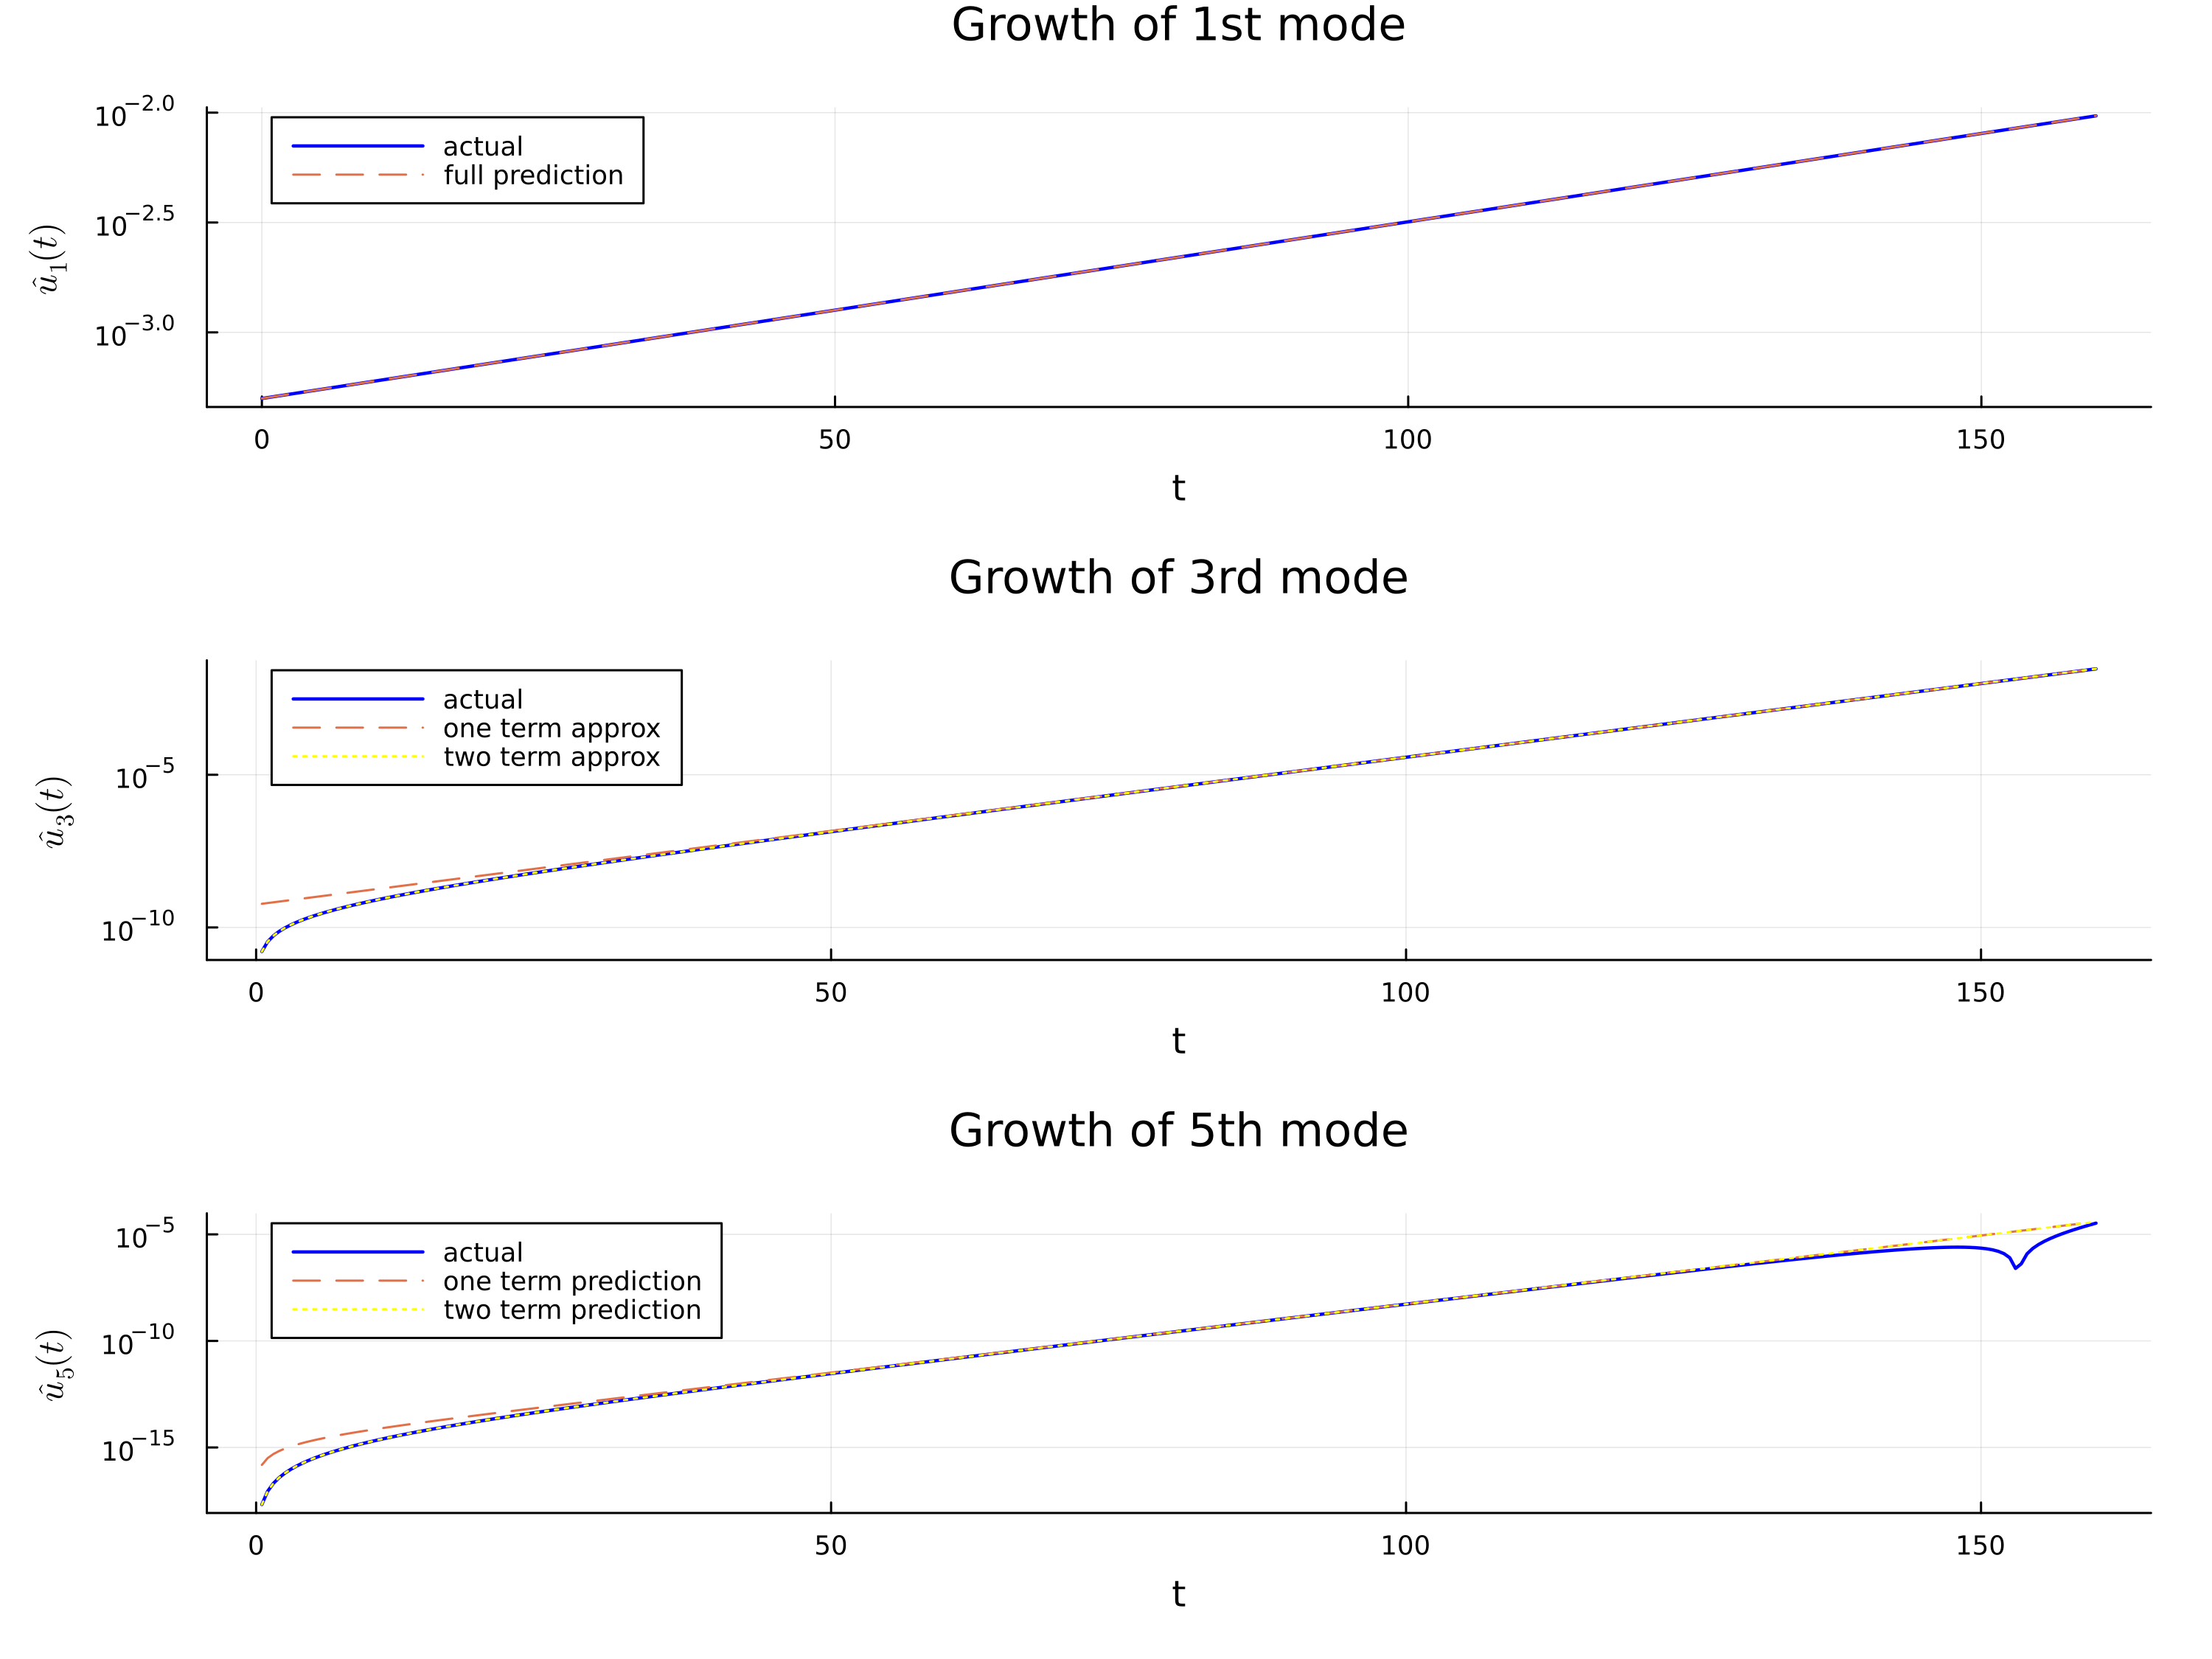

In [14]:
k(j) = pi / Lx * j
lambda(k) = mu * k^2 - k^4
t_plot = t_vec[plot_indices]

u_hat_1_act = u_hat_hist[2, :]
u_hat_1_pred = @. epsilon * exp(lambda(k(1)) * t_plot)

p1 = plot(t_plot, u_hat_1_act, 
    title="Growth of 1st mode", 
    xlabel="t", ylabel=L"\hat{u}_1(t)", yscale=:log10,
    linewidth=1.5, color=:blue, label="actual", legend=:topleft, grid=true)

plot!(p1, t_plot, u_hat_1_pred, label="full prediction", linestyle=:dash)

u_hat_3_act = u_hat_hist[4, :]
u_hat_3_pred = k(3)^2 * epsilon^3 / (lambda(k(3)) - 3 * lambda(k(1))) .* exp.(lambda(k(3)) .* t_plot)
u_hat_3_better_pred = k(3)^2 * epsilon^3 / (lambda(k(3)) - 3 * lambda(k(1))) .* abs.(exp.(3 * lambda(k(1)) .* t_plot) - exp.(lambda(k(3)) .* t_plot))

# Simply slice from index 2 to the end [2:end]
p3 = plot(t_plot[2:end], u_hat_3_act[2:end], 
    title="Growth of 3rd mode", 
    xlabel="t", ylabel=L"\hat{u}_3(t)", yscale=:log10,
    linewidth=1.5, color=:blue, label="actual", legend=:topleft, grid=true)

# Add your prediction lines using the same sliced time vector
plot!(p3, t_plot[2:end], u_hat_3_pred[2:end], label="one term approx", linestyle=:dash)
plot!(p3, t_plot[2:end], u_hat_3_better_pred[2:end], label="two term approx", linestyle=:dot, color=:yellow)

u_hat_5_act = u_hat_hist[6, :]

C5 = 3 * k(5)^2 * k(3)^2 * epsilon^5 / (lambda(k(3)) - 3 * lambda(k(1)))

u_hat_5_pred = C5 / (lambda(k(3)) + 2 * lambda(k(1))) .* (exp.((lambda(k(3)) + 2 * lambda(k(1))) .* t_plot) .- 1)

# First integration term (Matches your original u_hat_5_pred)
term1 = (exp.((lambda(k(3)) + 2 * lambda(k(1))) .* t_plot) .- 1) / (lambda(k(3)) + 2 * lambda(k(1)))

# Second integration term (Corrected with .- 1)
term2 = (exp.(5 * lambda(k(1)) .* t_plot) .- 1) / (5 * lambda(k(1)))

# Complete full prediction
u_hat_5_better_pred = abs.(C5 .* (term1 .- term2))

# Simply slice from index 2 to the end [2:end]
p5 = plot(t_plot[2:end], u_hat_5_act[2:end], 
    title="Growth of 5th mode", 
    xlabel="t", ylabel=L"\hat{u}_5(t)", yscale=:log10,
    linewidth=1.5, color=:blue, label="actual",legend=:topleft, grid=true)

# Add your prediction lines using the same sliced time vector
plot!(p5, t_plot[2:end], u_hat_5_pred[2:end], label="one term prediction", linestyle=:dash)
plot!(t_plot[2:end], u_hat_5_better_pred[2:end], label="two term prediction", linestyle=:dot, color=:yellow)

l = @layout [a ; b ; c]
plot(p1, p3, p5, layout=l, size=(1000, 750), margin=5Plots.mm, dpi=300)

In [15]:
savefig("odd_mode_growth.svg")

"/Users/jhaertel/code/bu_reu/odd_mode_growth.svg"

In [5]:
println("Generating Video...")
video_filename = "$(T_type)_k=$(round(k_i, digits=3))_T=$(round(T_end_float, digits=0)).mp4"
shifted_kx = fftshift(kx_float)

println("Time k3 dominates: ", dom_t[2])

l = @layout [a; b c]
anim = @animate for i in 1:num_frames
    current_t = t_vec[plot_indices[i]]
    
    p1 = plot(x_grid, u_hist[:, i], 
              title="t = $(round(current_t, digits=3))", 
              xlabel="x", ylabel="u", 
              linewidth=1.5, color=:blue, legend=false, 
              ylims=(-1.2 * sqrt(mu_float), 1.2 * sqrt(mu_float)), grid=true)
    
    plot_t = max(1e-2, current_t) 
    valid_idx = dom_t .<= plot_t
    cur_dom_t = dom_t[valid_idx]
    cur_dom_k = dom_k[valid_idx]
    
    if isempty(cur_dom_k)
        push!(cur_dom_t, plot_t)
        push!(cur_dom_k, dom_k[1])
    else
        push!(cur_dom_t, plot_t)
        push!(cur_dom_k, cur_dom_k[end])
    end
    
    p2 = plot(cur_dom_t, cur_dom_k, 
              linetype=:steppost, linewidth=2, 
              xlabel="t", ylabel="Wavenumber (k)", 
              xlims=(1e-2, T_end_float), ylims=(0, k_j[end]), 
              color=:blue, legend=false, grid=true)
    
    hline!(p2, k_j, linestyle=:dash, color=:red, alpha=0.6)
              
    u_hat_shifted_raw = fftshift(u_hat_hist[:, i])
    shifted_u_hat = @. max(u_hat_shifted_raw, 1e-70)
    
    p3 = plot(shifted_kx, shifted_u_hat, 
              linewidth=2, color=:blue, 
              xlabel="k", ylabel="|u_hat|", 
              yscale=:log10, xlims=(-10, 10), ylims=(1e-70, max(1.0, maximum(shifted_u_hat))), 
              legend=false, grid=true)
              
    plot(p1, p2, p3, layout=l, size=(1200, 700), margin=5Plots.mm, dpi=300)
end

mp4(anim, video_filename, fps=30)


println("Saved: $video_filename")

Generating Video...
Time k3 dominates: 147.97


LoadError: InterruptException: